## Physical parameters:

v = 1 cell / hour \
generation time = 10 hours (so edge thickness is 10 cells) \
Doubling time = 2-3 hours 


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.animation import FuncAnimation
from scipy.stats import linregress
from tqdm import tqdm
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from scipy.special import lambertw
%config InlineBackend.figure_format = 'png' # May solve the copy from cell issue

hex_start = "#fa6100"   # example: blue
hex_end   = "#1461f0"   # example: red

In [12]:
def simulate_plaques(
    v=1.0,
    pj=1e-4,
    pn=0.0,
    ag=0.0,
    ag_sig=0.0,
    dt=0.01,
    t_max=100.0,
    max_plaques=50000,
    seed=0,
    record_every=1,
    verbose=True,
):
    rng = np.random.default_rng(seed)

    birth_t = np.zeros(1, dtype=np.float64)
    halted  = np.zeros(1, dtype=bool)

    use_delay = (ag is not None) and (ag > 0.0)
    use_ag_i  = use_delay and (ag_sig is not None) and (ag_sig > 0.0)

    if use_ag_i:
        ag_i = rng.normal(loc=ag, scale=ag_sig, size=1).astype(np.float64)
        np.maximum(ag_i, 0.0, out=ag_i)
    else:
        ag_i = None

    times, n_plaques, n_active, total_area = [], [], [], []
    n_steps = int(np.ceil(t_max / dt))

    A_halt = (1.0 / pn) if (pn > 0.0) else np.inf
    vvpi = np.pi * (v * v)

    def area_from_time(t, birth_t_arr, ag_arr=None):
        if not use_delay:
            tau = t - birth_t_arr
        else:
            tau = (t - birth_t_arr - ag) if (ag_arr is None) else (t - birth_t_arr - ag_arr)
        tau = np.maximum(tau, 0.0)
        A = vvpi * (tau * tau)
        if np.isfinite(A_halt):
            A = np.minimum(A, A_halt)
        return A

    for step in range(n_steps + 1):
        t = step * dt

        A_cur = area_from_time(t, birth_t, ag_i)

        if step % record_every == 0:
            times.append(t)
            n_plaques.append(birth_t.size)
            n_active.append(np.count_nonzero(~halted))
            total_area.append(float(np.sum(A_cur)))

        if birth_t.size >= max_plaques:
            if verbose: print("Stopped due to max plaques")
            break
        if step == n_steps:
            if verbose: print("Stopped due to max time")
            break

        A_old = A_cur
        A_new = area_from_time(t + dt, birth_t, ag_i)
        dA = A_new - A_old
        dA[halted] = 0.0

        dA_tot = float(np.sum(dA))

        lam_birth = dA_tot * pj
        n_new = rng.poisson(lam_birth) if lam_birth > 0 else 0

        if np.isfinite(A_halt):
            newly_halted = (~halted) & (A_old < A_halt) & (A_new >= A_halt)
            if np.any(newly_halted):
                halted[newly_halted] = True

        if n_new > 0:
            remaining = max_plaques - birth_t.size
            if remaining > 0:
                n_add = min(n_new, remaining)

                w = dA.copy()
                w[w < 0] = 0.0
                wsum = w.sum()
                if wsum <= 0:
                    parent_idx = rng.integers(0, birth_t.size, size=n_add)
                else:
                    parent_idx = rng.choice(birth_t.size, size=n_add, replace=True, p=w / wsum)

                birth_t = np.concatenate([birth_t, np.full(n_add, t + dt, dtype=np.float64)])
                halted  = np.concatenate([halted,  np.zeros(n_add, dtype=bool)])

                if use_ag_i:
                    ag_new = rng.normal(loc=ag, scale=ag_sig, size=n_add).astype(np.float64)
                    np.maximum(ag_new, 0.0, out=ag_new)
                    ag_i = np.concatenate([ag_i, ag_new])

    t_end = times[-1] if times else 0.0
    A_end = area_from_time(t_end, birth_t, ag_i)
    radii_end = np.sqrt(A_end / np.pi)

    if verbose and birth_t.size > 0:
        print(f"Mean area = {total_area[-1] / birth_t.size:.3f}")

    meta = dict(
        v=v, pj=pj, pn=pn, ag=ag, ag_sig=ag_sig, dt=dt,
        t_max=t_max, record_every=record_every, max_plaques=max_plaques,
        A_halt=A_halt, use_delay=use_delay, use_ag_i=use_ag_i, seed=seed,
        ag_i=ag_i,
    )

    return (
        np.array(times),
        np.array(total_area),
        np.array(n_plaques),
        np.array(n_active),
        np.array(radii_end),
        birth_t,
        halted,
        meta,
    )


def plot_simulation(
    t, A, N, N_active=None,
    max_plaques=None,
    fit_min=10,
    fit_max_frac=0.9,
    fig=None,
    axes=None,
    show=True,
    plot_active_plaques=False,
    t_snaps=None,
    mean_a_snaps=None,
    mean_a_snaps_nb=None,
    pj=None,
    ag=None,
    lamb=None,
    legend_loc=None,
):
    """
    Plot total area and plaque counts with exponential fits.
    """
    t = np.asarray(t); A = np.asarray(A); N = np.asarray(N)
    labelsize = 16
    N_cap = max_plaques if max_plaques is not None else np.max(N)
    fit_mask = (N > fit_min) & (N < fit_max_frac * N_cap)

    t_fit = t[fit_mask]
    A_fit = A[fit_mask]
    N_fit = N[fit_mask]

    fit_info = {}

    if t_fit.size >= 2 and np.all(N_fit > 0):
        logN = np.log(N_fit)
        slope_N, intercept_N, r_value_N, _, _ = linregress(t_fit, logN)
        lambda_N = slope_N
        R2N = r_value_N**2
    else:
        slope_N = intercept_N = np.nan
        lambda_N = np.nan
        R2N = np.nan

    fit_info["N"] = dict(slope=slope_N, intercept=intercept_N, Lambda=lambda_N, r2=R2N)

    if t_fit.size >= 2 and np.all(A_fit > 0):
        logA = np.log(A_fit)
        slope_A, intercept_A, r_value_A, _, _ = linregress(t_fit, logA)
        lambda_A = slope_A
        R2A = r_value_A**2
    else:
        slope_A = intercept_A = np.nan
        lambda_A = np.nan
        R2A = np.nan

    fit_info["A"] = dict(slope=slope_A, intercept=intercept_A, Lambda_A=lambda_A, r2=R2A)

    n_panels = 3 if mean_a_snaps is not None else 2
    if axes is None:
        fig, axes = plt.subplots(n_panels, 1, figsize=(9, 4 * n_panels), sharex=True)
    axA, axN = axes[0], axes[1]
    axMean = axes[2] if n_panels == 3 else None

    axA.plot(t, A, label="Simulation", color=hex_start)
    if t_fit.size >= 2 and np.isfinite(slope_A):
        label_fit_A = r"Exp fit ($\lambda$=" + f"{lambda_A:.2g}" + r"h$^{-1}$))"
        axA.plot(t_fit, np.exp(intercept_A + slope_A * t_fit), "--", label=label_fit_A, color="k")
    axA.set_ylabel(r"Total area [d$_c^2$]", fontsize=labelsize)
    axA.set_yscale("log")
    axA.grid(alpha=0.3)
    axA.legend(fontsize=17)
    axA.tick_params(labelsize=14)
    axA.set_ylim(1)

    axN.plot(t, N, label="Simulation", color=hex_end)
    if N_active is not None and plot_active_plaques:
        axN.plot(t, np.asarray(N_active), label="Active plaques")
    if t_fit.size >= 2 and np.isfinite(slope_N):
        label_fit_N = r"Exp fit ($\lambda$=" + f"{lambda_N:.2g}" + r"h$^{-1}$)"
        axN.plot(t_fit, np.exp(intercept_N + slope_N * t_fit), "--", label=label_fit_N, color="k")
    axN.set_ylabel("Number of FOI", fontsize=labelsize)
    axN.set_yscale("log")
    axN.grid(alpha=0.3)
    axN.legend(fontsize=17)
    axN.tick_params(labelsize=14)

    if axMean is not None:
        axMean.plot(t_snaps, mean_a_snaps,    color=hex_start, linewidth=1.5,
                    label=r"$\langle A \rangle$ (only growing FOI)")
        axMean.plot(t_snaps, mean_a_snaps_nb, color=hex_end,   linewidth=1.5,
                    label=r"$\langle A \rangle$ (all FOI)")
        if pj is not None and ag is not None and lamb is not None:
            axMean.axhline(np.exp(ag * lamb) / pj, color="k", ls="-",
                           label=r"$e^{\lambda\cdot a_g}/p$")
            axMean.axhline(1 / pj, color="k", ls="--", label="1/p")
        axMean.set_ylabel(r"Mean FOI area [$\mathrm{d}_c^2$]", fontsize=16)
        axMean.set_yscale("log")
        axMean.set_ylim(1)
        if legend_loc is None:
            MEAN_LEG_X, MEAN_LEG_Y = 0.6, 0.35
            axMean.legend(fontsize=14, loc="center left", bbox_to_anchor=(MEAN_LEG_X, MEAN_LEG_Y))
        else:
            axMean.legend(fontsize=14, loc=legend_loc)
        axMean.tick_params(labelsize=14)

    axes[-1].set_xlabel("Time [hpi]", fontsize=labelsize)

    fig.tight_layout()
    if show:
        plt.show()

    return fig, axes, fit_info


def plot_radius_histogram(
    radii,
    dr,
    n_bins=30,
    r_min=None,
    r_max=None,
    normalize_by_binwidth=True,
    area_weighted=False,
    ax=None,
):
    """
    Histogram of plaque radii.
    """
    radii = np.asarray(radii)
    radii = radii[radii > 0]

    if r_min is None:
        r_min = radii.min()
    if r_max is None:
        r_max = radii.max()

    bins = np.linspace(r_min, r_max, n_bins + 1)
    weights = np.pi * radii**2 if area_weighted else None
    counts, edges = np.histogram(radii, bins=bins, weights=weights)

    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    bin_widths = edges[1:] - edges[:-1]

    if normalize_by_binwidth:
        y = counts / bin_widths
        ylabel = "Area density" if area_weighted else "Number density"
    else:
        y = counts
        ylabel = r"Total area [d$_c^2$]" if area_weighted else "Count"

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(bin_centers, y, "o-", lw=1.5)
    ax.set_xlabel("Radius")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

    return ax, bin_centers, y


def exp_fit_loglinear(t, y, y_min=10, y_max_frac=0.9, mask=None, require_positive=True):
    """
    Fit y(t) ~ exp(intercept + slope*t) by linear regression on log(y).
    """
    y = np.asarray(y)
    t = np.asarray(t)

    if y.size != t.size:
        raise ValueError("t and y must have same length")

    finite = np.isfinite(y) & np.isfinite(t)
    if require_positive:
        finite &= (y > 0)

    if mask is None:
        y_max = np.max(y) if y.size else np.nan
        mask = (y > y_min) & (y < y_max_frac * y_max) & finite
    else:
        mask = np.asarray(mask, dtype=bool)
        if mask.size != y.size:
            raise ValueError("mask must have same length as t and y")
        mask = mask & finite

    t_fit = t[mask]
    y_fit = y[mask]

    if t_fit.size < 3:
        return dict(
            slope=np.nan, intercept=np.nan, r2=np.nan, doubling_time=np.nan,
            n_fit=t_fit.size, t_fit=t_fit, y_fit=y_fit, yhat_fit=np.array([])
        )

    logy = np.log(y_fit)
    slope, intercept, r_value, _, _ = linregress(t_fit, logy)

    doubling_time = np.log(2) / slope if np.isfinite(slope) and slope > 0 else np.nan
    yhat_fit = np.exp(intercept + slope * t_fit)

    return dict(
        slope=slope,
        intercept=intercept,
        r2=r_value**2,
        doubling_time=doubling_time,
        n_fit=t_fit.size,
        t_fit=t_fit,
        y_fit=y_fit,
        yhat_fit=yhat_fit
    )


def scan_pj_r2(
    pj_values,
    v=1.0,
    dt=0.01,
    t_max=10000.0,
    max_plaques=200000,
    seed=0,
    record_every=1,
    fit_threshold=100,
    fit_y_max_frac=0.9,
):
    """
    Run the simulation for each pj in pj_values and record r2 for N(t) and A(t).
    """
    pj_values = np.asarray(pj_values, dtype=float)

    r2_N = np.full_like(pj_values, np.nan, dtype=float)
    r2_A = np.full_like(pj_values, np.nan, dtype=float)
    k_N  = np.full_like(pj_values, np.nan, dtype=float)
    k_A  = np.full_like(pj_values, np.nan, dtype=float)
    Td_N = np.full_like(pj_values, np.nan, dtype=float)
    Td_A = np.full_like(pj_values, np.nan, dtype=float)
    nfit_N = np.zeros_like(pj_values, dtype=int)
    nfit_A = np.zeros_like(pj_values, dtype=int)

    for i, pj in tqdm(enumerate(pj_values)):
        t, A, N, *_ = simulate_plaques(
            v=v, pj=pj, dt=dt, t_max=t_max, max_plaques=max_plaques,
            seed=seed, record_every=record_every, verbose=False
        )
        mask_N = (N > fit_threshold) & (N < fit_y_max_frac * np.max(N)) & np.isfinite(N) & np.isfinite(t)
        fitN = exp_fit_loglinear(t, N, mask=mask_N, require_positive=True)
        fitA = exp_fit_loglinear(t, A, mask=mask_N, require_positive=True)

        r2_N[i] = fitN["r2"]
        r2_A[i] = fitA["r2"]
        k_N[i]  = fitN["slope"]
        k_A[i]  = fitA["slope"]
        Td_N[i] = fitN["doubling_time"]
        Td_A[i] = fitA["doubling_time"]
        nfit_N[i] = fitN["n_fit"]
        nfit_A[i] = fitA["n_fit"]

    return dict(
        pj=pj_values,
        r2_N=r2_N, r2_A=r2_A,
        k_N=k_N,   k_A=k_A,
        Td_N=Td_N, Td_A=Td_A,
        nfit_N=nfit_N, nfit_A=nfit_A
    )


def scan_pn_r2(
    pn_values=None,
    *,
    pj=0.1,
    pn_min=1e-6,
    n_pn=30,
    v=1.0,
    dt=0.01,
    t_max=10000.0,
    max_plaques=200000,
    seed=0,
    record_every=1,
    fit_y_max_frac=0.9,
    fit_threshold=100,
    max_attempts=20,
    require_nfit=2,
):
    """
    Scan pn with fixed pj. For each pn, rerun (up to max_attempts) until
    the N-based mask contains at least require_nfit points.
    """
    pn_max = pj
    if pn_values is None:
        if pn_min <= 0:
            raise ValueError("pn_min must be > 0 for log spacing.")
        if pn_max <= pn_min:
            raise ValueError("Need pj (=pn_max) > pn_min for log spacing.")
        pn_values = np.logspace(np.log10(pn_min), np.log10(pn_max), n_pn)

    pn_values = np.asarray(pn_values, dtype=float)

    r2_N = np.full_like(pn_values, np.nan, dtype=float)
    r2_A = np.full_like(pn_values, np.nan, dtype=float)
    k_N  = np.full_like(pn_values, np.nan, dtype=float)
    k_A  = np.full_like(pn_values, np.nan, dtype=float)
    Td_N = np.full_like(pn_values, np.nan, dtype=float)
    Td_A = np.full_like(pn_values, np.nan, dtype=float)
    nfit_N = np.zeros_like(pn_values, dtype=int)
    nfit_A = np.zeros_like(pn_values, dtype=int)
    attempts_used = np.zeros_like(pn_values, dtype=int)

    for i, pn in tqdm(list(enumerate(pn_values)), total=len(pn_values)):
        accepted = False

        for attempt in range(1, max_attempts + 1):
            seed_try = seed + 10_000 * i + attempt

            t, A, N, *_ = simulate_plaques(
                v=v, pj=pj, pn=pn,
                dt=dt, t_max=t_max,
                max_plaques=max_plaques,
                seed=seed_try,
                record_every=record_every,
                verbose=False,
            )

            N_max = np.max(N) if len(N) else np.nan
            mask_N = (N > fit_threshold) & (N < fit_y_max_frac * N_max) & np.isfinite(N) & np.isfinite(t)

            if np.count_nonzero(mask_N) >= require_nfit:
                fitN = exp_fit_loglinear(t, N, mask=mask_N, require_positive=True)
                fitA = exp_fit_loglinear(t, A, mask=mask_N, require_positive=True)

                r2_N[i] = fitN["r2"]
                r2_A[i] = fitA["r2"]
                k_N[i]  = fitN["slope"]
                k_A[i]  = fitA["slope"]
                Td_N[i] = fitN["doubling_time"]
                Td_A[i] = fitA["doubling_time"]
                nfit_N[i] = fitN["n_fit"]
                nfit_A[i] = fitA["n_fit"]

                attempts_used[i] = attempt
                accepted = True
                break

        if not accepted:
            attempts_used[i] = max_attempts

    return dict(
        pn=pn_values,
        pj=float(pj),
        r2_N=r2_N, r2_A=r2_A,
        k_N=k_N,   k_A=k_A,
        Td_N=Td_N, Td_A=Td_A,
        nfit_N=nfit_N, nfit_A=nfit_A,
        attempts=attempts_used,
    )


def powerlaw_fit(x, y, x_min=None, x_max=None, y_min=0.0, r2_min=0.0):
    """
    Fit y = C * x^alpha via log-log regression.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > y_min)

    if x_min is not None:
        mask &= (x >= x_min)
    if x_max is not None:
        mask &= (x <= x_max)

    x_fit = x[mask]
    y_fit = y[mask]

    if x_fit.size < 3:
        return dict(alpha=np.nan, C=np.nan, r2=np.nan, x_fit=x_fit, y_fit=y_fit, yhat_fit=np.array([]))

    logx = np.log(x_fit)
    logy = np.log(y_fit)

    slope, intercept, r_value, _, _ = linregress(logx, logy)
    alpha = slope
    C = np.exp(intercept)
    r2 = r_value**2

    yhat_fit = C * (x_fit ** alpha)

    return dict(alpha=alpha, C=C, r2=r2, x_fit=x_fit, y_fit=y_fit, yhat_fit=yhat_fit)


def scan_v_pj_doubling(
    v_values,
    pj_values,
    *,
    pn=0.0,
    dt=0.01,
    t_max=10000.0,
    max_plaques=200000,
    seed=0,
    record_every=1,
    fit_threshold=1000,
    fit_y_max_frac=0.9,
    require_nfit=3,
    fit_area_too=True,
    verbose=False,
):
    """
    2D scan over (v, pj) with fixed pn. For each parameter pair,
    run simulate_plaques and extract doubling time from an exponential fit.
    """
    v_values  = np.asarray(v_values,  dtype=float)
    pj_values = np.asarray(pj_values, dtype=float)

    nv  = v_values.size
    npj = pj_values.size

    Td_N  = np.full((nv, npj), np.nan, dtype=float)
    R2_N  = np.full((nv, npj), np.nan, dtype=float)
    k_N   = np.full((nv, npj), np.nan, dtype=float)
    nfitN = np.zeros((nv, npj), dtype=int)

    Td_A  = np.full((nv, npj), np.nan, dtype=float) if fit_area_too else None
    R2_A  = np.full((nv, npj), np.nan, dtype=float) if fit_area_too else None
    k_A   = np.full((nv, npj), np.nan, dtype=float) if fit_area_too else None
    nfitA = np.zeros((nv, npj), dtype=int)          if fit_area_too else None

    for iv, v in enumerate(tqdm(v_values, desc="scan v", disable=not verbose)):
        for ipj, pj in enumerate(pj_values):
            seed_ij = seed + 10_000 * iv + ipj

            t, A, N, *_ = simulate_plaques(
                v=v, pj=pj, pn=pn,
                dt=dt, t_max=t_max,
                max_plaques=max_plaques,
                seed=seed_ij,
                record_every=record_every,
                verbose=False,
            )

            if len(N) < 3 or not np.any(np.isfinite(N)):
                continue

            N_max = np.max(N)
            mask_N = (
                np.isfinite(t) & np.isfinite(N) &
                (N > fit_threshold) &
                (N < fit_y_max_frac * N_max)
            )

            if np.count_nonzero(mask_N) < require_nfit:
                continue

            fitN = exp_fit_loglinear(t, N, mask=mask_N, require_positive=True)

            Td_N[iv, ipj]  = fitN["doubling_time"]
            R2_N[iv, ipj]  = fitN["r2"]
            k_N[iv, ipj]   = fitN["slope"]
            nfitN[iv, ipj] = fitN["n_fit"]

            if fit_area_too:
                fitA = exp_fit_loglinear(t, A, mask=mask_N, require_positive=True)
                Td_A[iv, ipj]  = fitA["doubling_time"]
                R2_A[iv, ipj]  = fitA["r2"]
                k_A[iv, ipj]   = fitA["slope"]
                nfitA[iv, ipj] = fitA["n_fit"]

    out = dict(
        v=v_values,
        pj=pj_values,
        pn=float(pn),
        Td_N=Td_N, R2_N=R2_N, k_N=k_N, nfit_N=nfitN,
    )

    if fit_area_too:
        out.update(dict(Td_A=Td_A, R2_A=R2_A, k_A=k_A, nfit_A=nfitA))

    return out

In [13]:
def Lamb0(ag, k):
    """
    Compute lambda_0 = (2/ag) * W((ag/2)*k)

    Parameters
    ----------
    ag : float or array
    k : float or array  (k = sqrt of the birth rate parameter)
    branch : int
        Lambert W branch (default 0 = principal branch)

    Returns
    -------
    float or array (real part)
    """
    if ag == 0:
        return k
    else:
        z = (ag/2) * k
        return (2/ag) * lambertw(z, 0).real

In [14]:
IAV_params = {
    "v": 1,
    "ag": 6,
    "pn": 5e-3,
    "lambda": 0.25,
    "p": 0.0752
}

IAV_corrected_params = {
    "v": 1,
    "ag": 6,
    "pn": 5e-4,
    "lambda": 0.25,
    "p": 0.001,
}

WT_params = {
    "v": 1,
    "ag": 16,
    "pn": 1e-4,
    "lambda": 0.25,
    "p": 0.543
}

delta_params = {
    "v": 1,
    "ag": 12,
    "pn": 1e-4,
    "lambda": 0.25,
    "p": 0.2
}

In [15]:
# ---- Example run + plots ----
chosen_params = IAV_params
V = chosen_params["v"]
PJ = chosen_params["p"]
PN = chosen_params["pn"]
AG = chosen_params["ag"]

dt = 0.1
t_max = 48.0 if chosen_params == IAV_params else 72.
max_plaques = 10000000
seed = None

t, A, N, N_active, radii, birth_t, halted, meta = simulate_plaques(
    v=V, pj=PJ, pn=PN, dt=dt, t_max=t_max,
    max_plaques=max_plaques, seed=seed, ag = AG
)

# True total area from simulation
area_true = np.sum(np.pi * radii**2)
print(area_true/len(radii))

Stopped due to max time
Mean area = 13.341
13.340802001531198


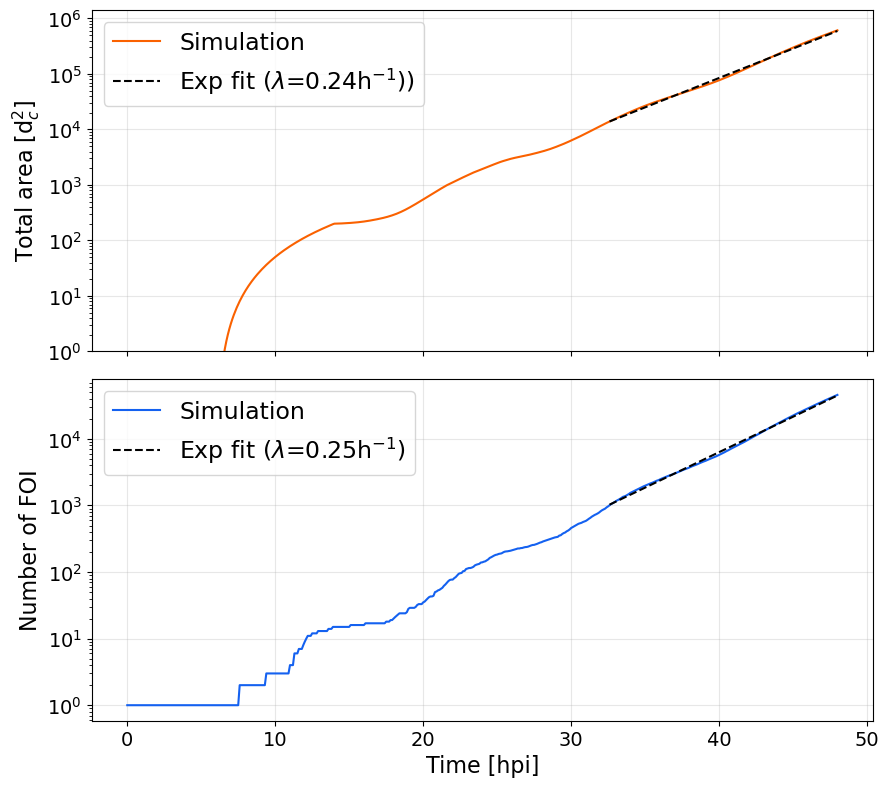

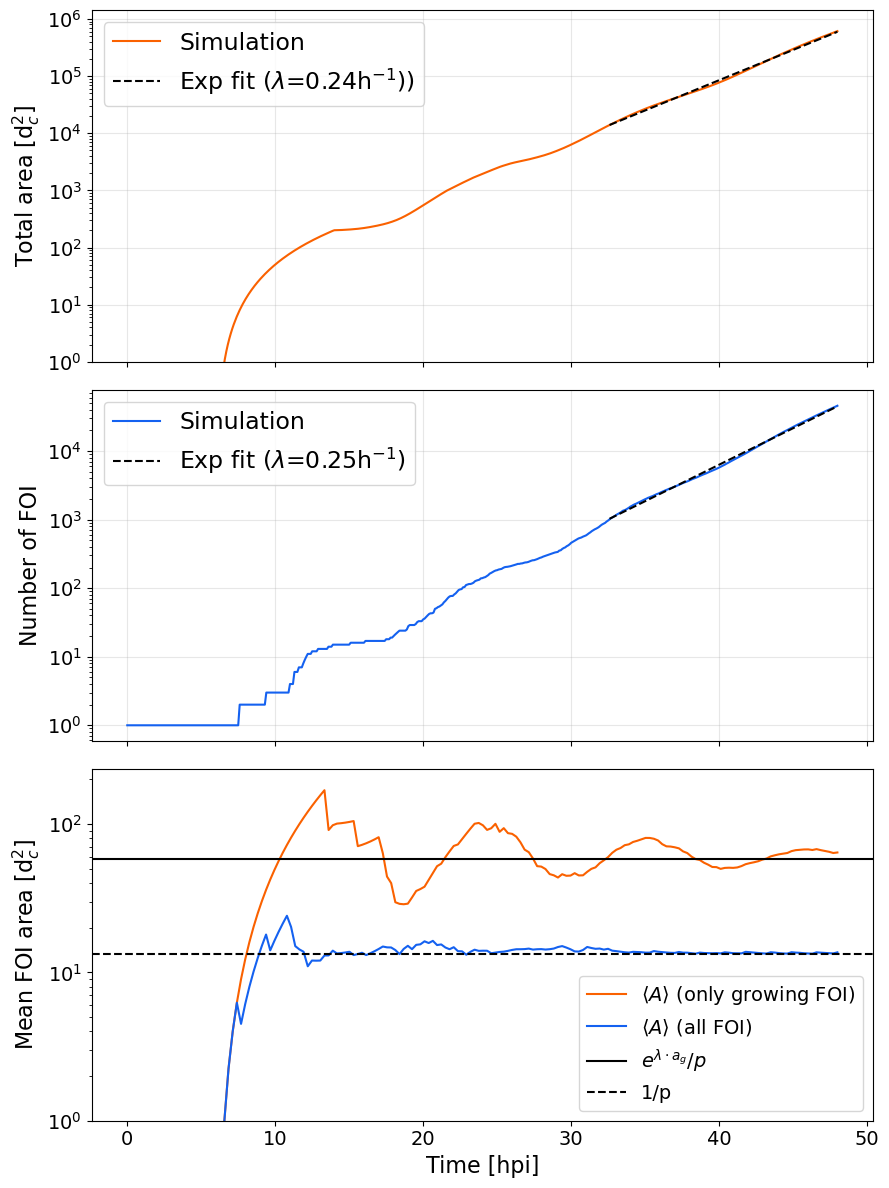

In [16]:
#Step 1: hidden call to extract fit lambda
_fig_tmp, _, _fit = plot_simulation(
    t, A, N, N_active=N_active, max_plaques=max_plaques, fit_min=1000, show=True
)
lamb = _fit["N"]["Lambda"]
plt.close(_fig_tmp)

if PN == 0:
    k = np.sqrt(2*np.pi*PJ*V**2)
    print(f"Predicted lambda = {Lamb0(AG,k)}")

# Compute mean-area snapshots for the third panel
# (cell 7 will overwrite these with identical values when run)
_r_halt = np.sqrt(1.0 / (np.pi * PN)) if PN > 0 else np.inf
_n_snaps = 150
t_snaps         = np.linspace(AG, t[-1], _n_snaps)
mean_a_snaps    = np.zeros(_n_snaps)
mean_a_snaps_nb = np.zeros(_n_snaps)
for _fi, _ts in enumerate(t_snaps):
    _mask = birth_t <= _ts
    _tau  = np.maximum(_ts - birth_t[_mask] - AG, 0.0)
    _r    = V * _tau
    if np.isfinite(_r_halt):
        _r = np.minimum(_r, _r_halt)
    if len(_r) > 0:
        _w = np.pi * _r**2
        mean_a_snaps_nb[_fi] = np.mean(_w)
        _rg = _r[_r > 0]
        if len(_rg) > 0:
            mean_a_snaps[_fi] = np.mean(np.pi * _rg**2)

# Step 2: full 3-panel figure
results = plot_simulation(
    t, A, N, N_active=N_active, max_plaques=max_plaques, fit_min=1000,
    t_snaps=t_snaps, mean_a_snaps=mean_a_snaps, mean_a_snaps_nb=mean_a_snaps_nb,
    pj=PJ, ag=AG, lamb=lamb, legend_loc="lower right"
)